# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [1]:
pip install pandas requests lxml

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Paso 1: Instalación de dependencias
Asegúrate de que tienes instalados los paquetes pandas y requests de Python para poder trabajar en el proyecto. En el caso de que no tengas las librerías instaladas, ejecuta en la consola:


In [2]:
import os
from bs4 import BeautifulSoup
import pandas as pd
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import io
from urllib.request import urlopen
%matplotlib inline

url = "https://www.hubertiming.com/results/summary/2017GPTR10K"
resp = requests.get(url)
print("Estado:", resp.status_code)


Estado: 200


Paso 2: Descargar HTML
La descarga del HTML de la página web se realizará con la librería requests, como vimos en la teoría del módulo.

La página web que queremos scrapear es la siguiente: https://www.hubertiming.com/results/summary/2017GPTR10K. Recopila y almacena información y guarda el texto scrapeado de la web en alguna variable.

In [3]:
html = io.StringIO(resp.text)
tables = pd.read_html(html)
print(f"Hay {len(tables)} tablas.")

df = tables[0] 
df = df.dropna()

Hay 5 tablas.


Paso 3: Transforma el HTML
Con BeautifulSoup, analizá el HTML para encontrar la estructura que contiene los datos (por ejemplo: <table>, <li>, <div>, etc.).

Si usás Wikipedia y contiene una tabla, podés usar directamente pandas.read_html() para cargarla como DataFrame.

In [4]:
soup = BeautifulSoup(html, 'lxml')
type(soup)

text = soup.get_text()
print(text)









Race results for the 2017 Intel Great Place to Run \ Urban Clash Games!





















 2017 Intel Great Place to Run 10K \ Urban Clash Games
 Hillsboro Stadium, Hillsboro, OR 
 June 2nd, 2017


                            





 Email
                        timing@hubertiming.com with results questions. Please include your bib number if you have it.


                    






Huber Timing Home













 5K Individual
 5K Team
 10K Individual
 10K Team
 Summary




Event
Finishers
Male
Female


5K
1458
771
687

10K
577
414
163;

Total
2035
1185
850


5K Top Results




Place
Male Finisher
Age
Chip Time
Gun Time

1DANIEL M HINCKLEY2616:4216:442KORY F GRAY2617:3417:353FILIP SCHMOLE3618:1318:144TRENTON C ROLLING3618:3218:355YEAN-AN LIAO3619:1219:186JORGE1 LOPEZ3619:1919:207SCOTT E HAMPSHIRE2619:2719:298KEVIN CANADA2819:5320:029SCOTT GERWIG4619:5719:5910NICOLAUS L ROCK3620:0020:01





Place
Female Finisher
Age
Chip Time
Gun Time

1ANNIE C DUONG3621:4821:522 CHRISTINE A

Paso 4: Procesa el DataFrame
A continuación, limpia las filas para obtener los valores limpios eliminando $ y B. Elimina también aquellas que estén vacías o no tengan información.

In [5]:
table_info0 = tables[0]
table_info0

df0 = tables[0] 
df0.columns = ["Event", "Finishers", "Male", "Female"]

df["Event"] = df["Event"].str.replace(r"\[.*?\]", "", regex=True)
df['Event'] = df['Event'].str.strip()

df["Finishers"] = df["Finishers"].astype(int)
df["Male"] = df["Male"].astype(int)
df["Female"] = df["Female"].astype(int)

table_info1 = tables[1]
table_info1

table_info2 = tables[2]
table_info2

table_info3 = tables[3]
table_info3

table_info4 = tables[4]
table_info4


,Place,Female Finisher,Age,Chip Time,Gun Time
0,1,SAMANTHA BAGLEY,18,43:46,43:53
1,2,TAYSEER MAHDI,26,43:47,43:52
2,3,JANELLE M KLASER,36,44:07,44:17
3,4,FUMIE K WEIBY,36,45:40,46:02
4,5,INGA ANDREYEVA,18,46:45,46:57
5,6,AURORE LARIVEN,36,46:52,47:09
6,7,MALLORY TYLER,18,47:09,47:30
7,8,LYNNETTE NGUYEN,36,47:31,47:36
8,9,REBECCA JENSEN,26,47:35,47:59
9,10,AI SSA CHAI,36,47:56,48:09


Paso 5: Almacena los datos en sqlite
Crea una instancia vacía de la base de datos e incluye en ella los datos limpios, como vimos en el módulo de bases de datos. Una vez tengas una base de datos vacía:

Crea la tabla.
Inserta los valores.
Almacena (commit) los cambios.

In [6]:
race = sqlite3.connect("great_place_to_run.db")
print(race)

df.to_sql("race_summary", race, if_exists="replace", index=False)
cursor = race.cursor()

cursor.execute("SELECT COUNT(*) FROM most_streamed")
print("Rows inserted:", cursor.fetchone()[0])

race.commit()
race.close()

Rows inserted: 3


In [7]:
print(tables[1], df.columns)

   Place      Male Finisher  Age Chip Time Gun Time
0      1  DANIEL M HINCKLEY   26     16:42    16:44
1      2        KORY F GRAY   26     17:34    17:35
2      3      FILIP SCHMOLE   36     18:13    18:14
3      4  TRENTON C ROLLING   36     18:32    18:35
4      5       YEAN-AN LIAO   36     19:12    19:18
5      6       JORGE1 LOPEZ   36     19:19    19:20
6      7  SCOTT E HAMPSHIRE   26     19:27    19:29
7      8       KEVIN CANADA   28     19:53    20:02
8      9       SCOTT GERWIG   46     19:57    19:59
9     10    NICOLAUS L ROCK   36     20:00    20:01 Index(['Event', 'Finishers', 'Male', 'Female'], dtype='str')


Paso 6: Visualiza los datos (opcional, pero muy recomendado)
Si aún no has revisado los conceptos y prácticas de visualización, no te preocupes. Intenta hacer que esto funcione, y exploraremos la visualización en detalle en los próximos proyectos.

¿Qué tipos de visualizaciones podemos realizar? Propón al menos 3 y muéstralos.

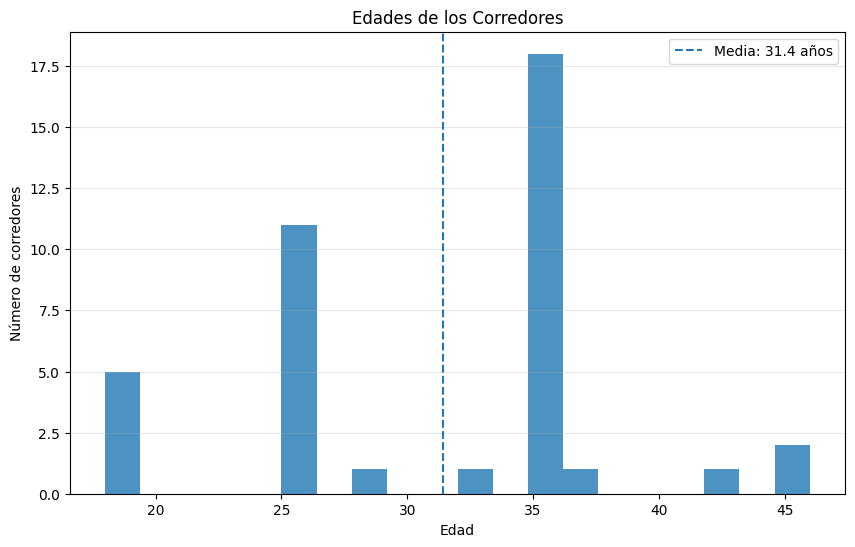

In [8]:
df_edades = pd.concat([tables[1], tables[2], tables[3], tables[4]])
df_edades['Age'] = pd.to_numeric(df_edades['Age'], errors='coerce')
df_edades = df_edades.dropna(subset=['Age'])

media_edad = df_edades['Age'].mean()

plt.figure(figsize=(10, 6))
plt.hist(df_edades['Age'], bins=20, alpha=0.8)
plt.axvline(media_edad, linestyle='dashed', label=f'Media: {media_edad:.1f} años')
plt.title('Edades de los Corredores')
plt.xlabel('Edad')
plt.ylabel('Número de corredores')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


En esta gráfica podemos obervar las edades de los corredores y la edad media de todos los participantes, se puede ver un pico alto a los 35 y otro considerable sobre los 26. La edad media es de 31,4.

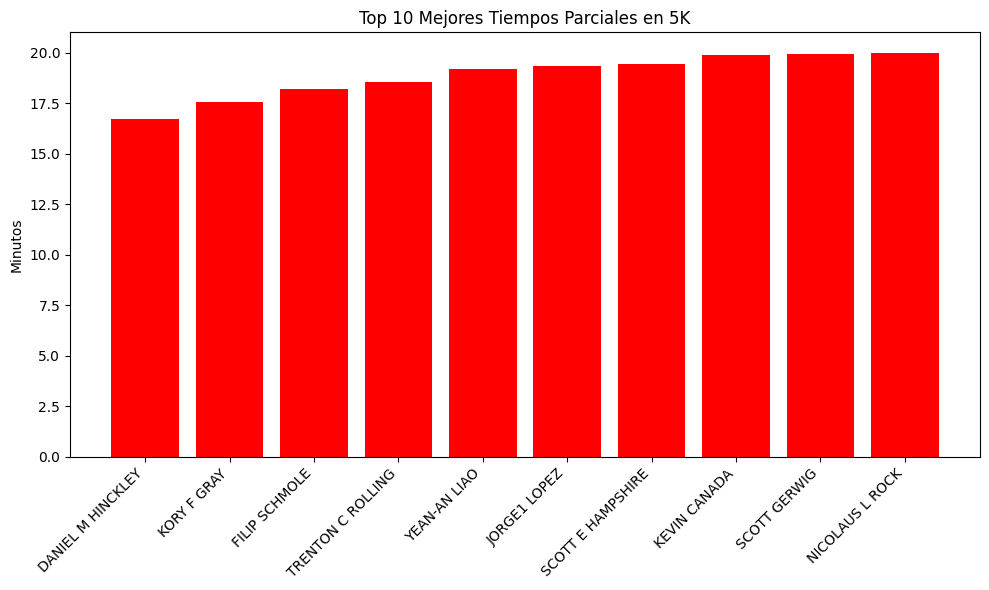

In [9]:
def time_to_min(t):
    m, s = t.split(':')
    return int(m) + int(s)/60

df_male = tables[1]

def time_to_min(t):
    m, s = t.split(':')
    return int(m) + int(s)/60

df_male['5K_Min'] = df_male['Chip Time'].apply(time_to_min)
df_male = df_male.rename(columns={'Male Finisher': 'Name'})
mejores_5k = df_male.sort_values('5K_Min').head(10)

plt.figure(figsize=(10,6))
plt.bar(mejores_5k['Name'], mejores_5k['5K_Min'], color='red')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Mejores Tiempos Parciales en 5K')
plt.ylabel('Minutos')
plt.tight_layout()
plt.show()


En esta gráfica podemos apreciar, como va incrementando el tiempo en los siguientes participantes tras la llegada del primer corredor.

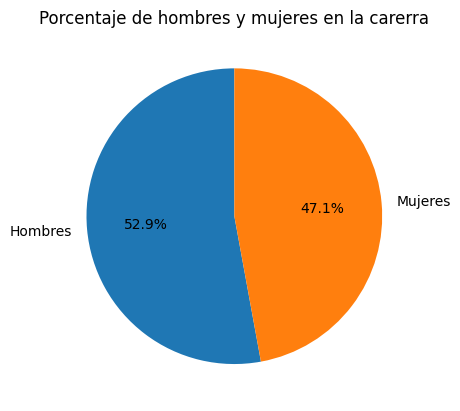

In [10]:
df_edades = pd.concat([tables[1], tables[2]])

df_edades['Age'] = pd.to_numeric(df_edades['Age'], errors='coerce')
df_edades = df_edades.dropna(subset=['Age'])

df_genero = tables[0]

labels = ['Hombres', 'Mujeres']
sizes = df_genero.loc[0, ['Male', 'Female']]

plt.pie(
    sizes,
    labels = labels,
    autopct = '%1.1f%%',
    startangle = 90
)
plt.title('Porcentaje de hombres y mujeres en la carerra')
plt.show()


En esta gráfica podemos apreciar la leve diferencia que hay entre hombre y mujeres en la carrera que se corrió.